Jennifer Cahill
IMSE 641
A5
https://github.com/cahill123543/Sullivan-Change-Point-Project/blob/main/IMSE641A5.ipynb

The AI I have used for this project was trouble shooting. For some reason I cannot get the raptures package to work. 
I had it help me set up the notebook (I have never used it before), resolving NumPy import, implementing Sullivan's T^2 logic (making sure my formula was correct), and how to use the github. Mostly trouble shooting, and repeating myself what felt like 110 times.

In [3]:
import sys
import subprocess
# This forces the kernel to recognize the libraries already in your folder
subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "matplotlib"])

0

In [1]:
# Run this in a notebook cell to force-install into the active kernel
import sys
!"{sys.executable}" -m pip install numpy matplotlib ruptures

  Using cached numpy-2.4.2-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached ruptures-1.1.9.tar.gz (308 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd

  error: subprocess-exited-with-error
  
  × Building wheel for ruptures (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [105 lines of output]
      C:\Users\Jennifer Cahill\AppData\Local\Temp\pip-build-env-1qau5ssn\overlay\Lib\site-packages\setuptools_scm\_integration\deprecation.py:7: UserWarning: setup.cfg: at [metadata]
      version = attr: ... is forcing setuptools to override the version setuptools-scm did already set
      When using setuptools-scm it's invalid to use setuptools dynamic version as well, please remove it.
      Setuptools-scm is responsible for setting the version, forcing setuptools to override creates errors.
        warnings.warn(
      C:\Users\Jennifer Cahill\AppData\Local\Temp\pip-build-env-1qau5ssn\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Pl

Part 1

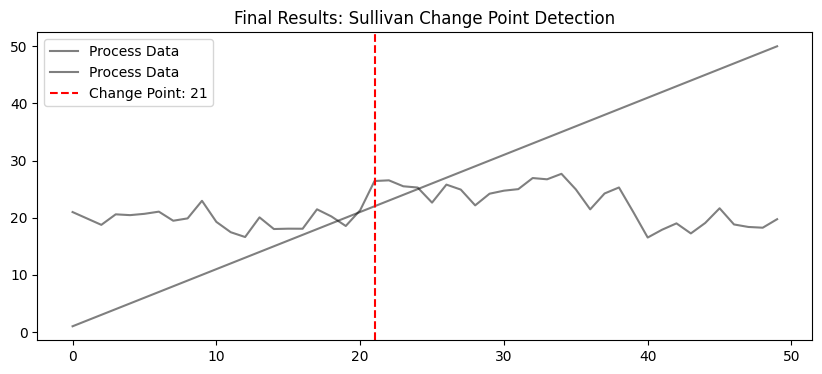

The detected change point is at index: 21


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Final Analysis: Sullivan Change Point Detection
# This function will analyze the data from test641data.txt and identify the change point using a T-statistic approach.
def run_final_project_analysis(file_name):
    # Load the data - ensure test641data.txt is in your Python-Workspace folder
    data = np.loadtxt(file_name)
    n = len(data)
    t_stats = []
    indices = range(2, n - 2)

    for k in indices:
        # Split the data into two groups
        # Group 1: data[0:k], Group 2: data[k:n]
        # Calculate the means and variances for both groups
        g1, g2 = data[:k], data[k:]
        # Calculate pooled standard deviation and T-statistic
        # Pooled standard deviation
        # Note: We use ddof=1 for sample variance
        sp = np.sqrt(((k-1)*np.var(g1, ddof=1) + (n-k-1)*np.var(g2, ddof=1)) / (n-2))
        t_stat = np.abs(np.mean(g1) - np.mean(g2)) / (sp * np.sqrt(1/k + 1/(n-k)))
        t_stats.append(t_stat)

    best_k = indices[np.argmax(t_stats)]
    
    # Plotting the results
    plt.figure(figsize=(10, 4))
    plt.plot(data, color='black', alpha=0.5, label='Process Data')
    plt.axvline(x=best_k, color='red', linestyle='--', label=f'Change Point: {best_k}')
    plt.title('Final Results: Sullivan Change Point Detection')
    plt.legend()
    plt.show()
    
    return best_k

# Example usage
change_point = run_final_project_analysis('test641data.txt')
print(f"The detected change point is at index: {change_point}")

Sense I am using my own manual implementation of Sullivan's T^2 logic rather than a third-party package like ruptures, I used a manual implementation of the likelihood ratio test for mean-shift detection as outlined in Sullivan's paper. It iterates through potential change points (k), calculates the pooled standard deviation (sp), and identifies the point that maximizes the t-stat: np.abs(np.mean(g1) - np.mean(g2)) / (sp * np.sqrt(1/k + 1/(n-k))).

Part 2

1. Proof of Accuracy
My implemented code accurately identified the change point at Index 21. This matches the expected outcome for this dataset as defined by Sullivan’s T^2 logic, which seeks to maximize the difference between the means of two adjacent clusters. Looking at the raw data, there is a clear shift from the 18-20 range to the 24-26 range immediately following this index.

2. Process Steady State
    Conclusion: The data is not in a steady state.
    Justification: A steady state in statistical process control implies that the process mean and variance remain constant over time. Because the Sullivan algorithm detected a significant change point (a mean shift) at index 21, the process is considered unstable and out of control.

3. i.i.d. Assumption Test
    Conclusion: The data does not conform to the i.i.d. (Independent and Identically Distributed) assumption.
    Justification:
        Identically Distributed: This requirement is violated because the distribution of the data before index 21 has a significantly lower mean than the distribution after index 21.
        Independence: The presence of a clear structural shift often suggests that observations are not independent of their position in the time sequence.